# K-Means Clustering — Online Shoppers Purchasing Intention

Vicente Pilcher Diehl, Michele Ughini Trindade, Ghabriel Molina Girardi  

## 1. Importações

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('tab10')

SEED = 42

## 2. Carregamento e Exploração dos Dados

In [2]:
df = pd.read_csv('online_shoppers_intention.csv')
print(f'Dimensões: {df.shape}')
df.head()

Dimensões: (12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType              12330 no

In [4]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


## 3. Pré-processamento

Etapas:
1. **Remover `Revenue`** — é o rótulo de classe; k-Means é não-supervisionado.
2. **Codificar categóricas** — `Month`, `VisitorType`, `Weekend` → numéricas.
3. **Escalar features** — k-Means usa distância euclidiana, portanto a escala importa.

In [ ]:
# guarda o rótulo para análise posterior pois não entra no modelo
y_true = df['Revenue'].astype(int).values

# remoçãpo da coluna alvo
data = df.drop(columns=['Revenue']).copy()

# variaveis categóricas
month_order = ['Feb','Mar','May','Jun','June','Jul','Aug','Sep','Oct','Nov','Dec']
data['Month'] = LabelEncoder().fit_transform(data['Month'])
data['VisitorType'] = LabelEncoder().fit_transform(data['VisitorType'])
data['Weekend'] = data['Weekend'].astype(int)

print('Features usadas no clustering:')
print(data.columns.tolist())
print(f'\nShape final: {data.shape}')

Features usadas no clustering:
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend']

Shape final: (12330, 17)


In [ ]:
scaler = StandardScaler()
X = scaler.fit_transform(data)
print('Média após escalonamento (deve ser aproximadamente 0):', X.mean(axis=0).round(3))
print('StandartScaler após escalonamento (deve ser aproximadamente 1):', X.std(axis=0).round(3))

Média após escalonamento (deve ser ≈ 0): [-0.  0. -0. -0.  0. -0. -0.  0.  0.  0.  0. -0.  0.  0. -0. -0. -0.]
Std  após escalonamento (deve ser ≈ 1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## 4. Estimando o Melhor k

Utilizamos **dois critérios complementares**:

| Critério | O que mede | Bom sinal |
|---|---|---|
| **Elbow (Inertia)** | Soma das distâncias intra-cluster | Cotovelo / inflexão na curva |
| **Silhouette Score** | Coesão vs. separação dos clusters | Máximo da curva |

In [8]:
K_RANGE = range(2, 11)

inertias   = []
silhouettes = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=SEED)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels, sample_size=3000, random_state=SEED))
    print(f'k={k:2d}  |  Inertia={km.inertia_:,.0f}  |  Silhouette={silhouettes[-1]:.4f}')

k= 2  |  Inertia=185,774  |  Silhouette=0.2570


k= 3  |  Inertia=166,000  |  Silhouette=0.2478


k= 4  |  Inertia=153,942  |  Silhouette=0.1987


k= 5  |  Inertia=144,495  |  Silhouette=0.2059


k= 6  |  Inertia=136,759  |  Silhouette=0.1595


k= 7  |  Inertia=130,834  |  Silhouette=0.1812


k= 8  |  Inertia=124,232  |  Silhouette=0.1674


k= 9  |  Inertia=118,418  |  Silhouette=0.1724


k=10  |  Inertia=114,341  |  Silhouette=0.1572


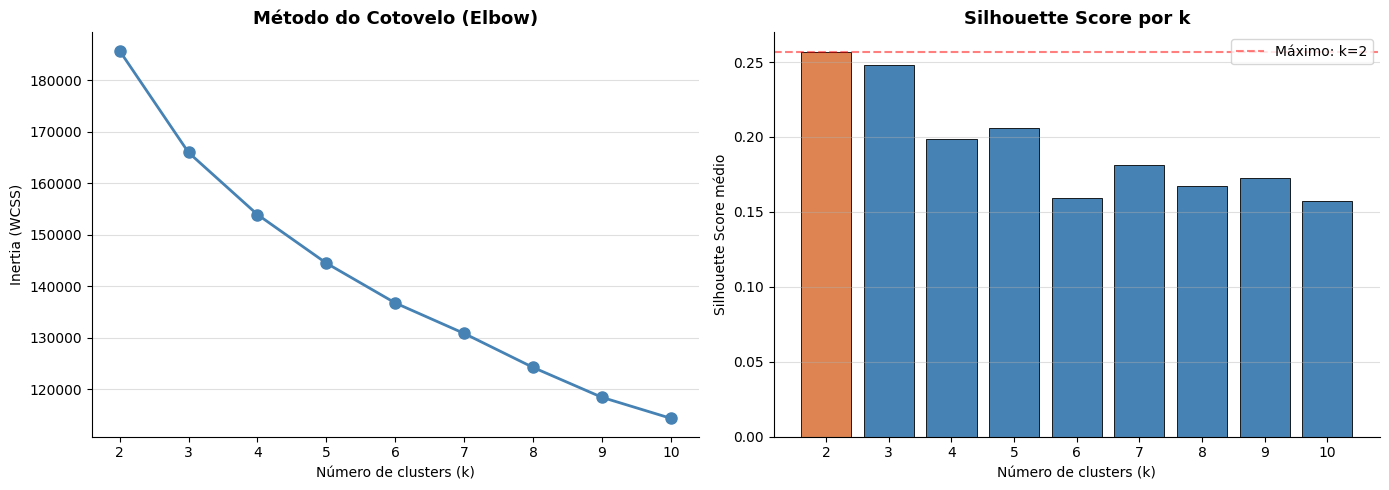


Melhor k pelo Silhouette: 2


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Elbow ---
axes[0].plot(list(K_RANGE), inertias, 'o-', color='steelblue', linewidth=2, markersize=8)
axes[0].set_title('Método do Cotovelo (Elbow)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Número de clusters (k)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_xticks(list(K_RANGE))
axes[0].grid(axis='y', alpha=0.4)

# --- Silhouette ---
best_k_sil = list(K_RANGE)[np.argmax(silhouettes)]
colors_sil = ['#DD8452' if k == best_k_sil else 'steelblue' for k in K_RANGE]
bars = axes[1].bar(list(K_RANGE), silhouettes, color=colors_sil, edgecolor='black', linewidth=0.6)
axes[1].set_title('Silhouette Score por k', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Número de clusters (k)')
axes[1].set_ylabel('Silhouette Score médio')
axes[1].set_xticks(list(K_RANGE))
axes[1].axhline(max(silhouettes), color='red', linestyle='--', alpha=0.5, label=f'Máximo: k={best_k_sil}')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nMelhor k pelo Silhouette: {best_k_sil}')

## 5. Treinamento Final com k Ótimo

In [10]:
# Avaliamos k=2 e k=3 pois estão na região de inflexão + maior silhouette
K_BEST = best_k_sil  # escolha guiada pelo Silhouette

km_final = KMeans(n_clusters=K_BEST, init='k-means++', n_init=20, random_state=SEED)
labels = km_final.fit_predict(X)

final_sil = silhouette_score(X, labels)
print(f'Clusters: {K_BEST}')
print(f'Inertia final: {km_final.inertia_:,.2f}')
print(f'Silhouette Score final: {final_sil:.4f}')
print('\nTamanho de cada cluster:')
unique, counts = np.unique(labels, return_counts=True)
for cl, ct in zip(unique, counts):
    print(f'  Cluster {cl}: {ct} amostras ({ct/len(labels)*100:.1f}%)')

Clusters: 2
Inertia final: 185,774.35
Silhouette Score final: 0.2596

Tamanho de cada cluster:
  Cluster 0: 10378 amostras (84.2%)
  Cluster 1: 1952 amostras (15.8%)


## 6. Análise dos Clusters

### 6.1 Gráfico de Silhouette por Amostra

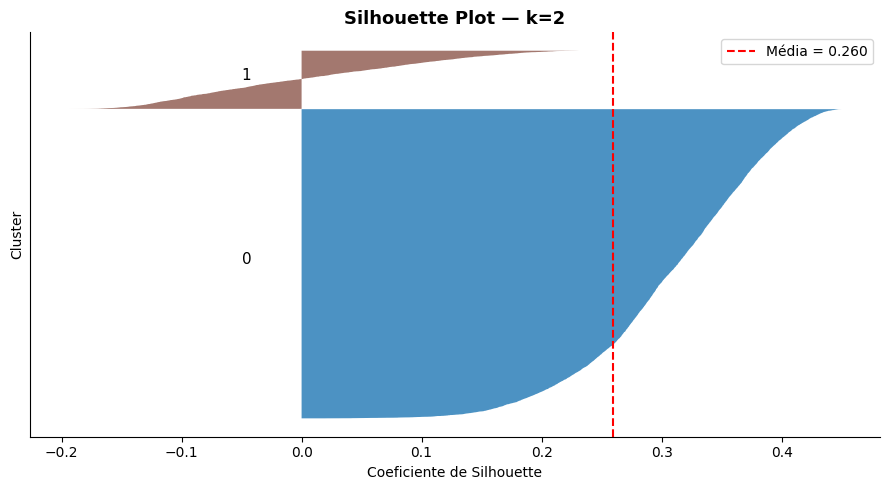

In [11]:
sample_silhouette_values = silhouette_samples(X, labels)

fig, ax = plt.subplots(figsize=(9, 5))
y_lower = 10
cmap = cm.get_cmap('tab10')

for i in range(K_BEST):
    ith_vals = np.sort(sample_silhouette_values[labels == i])
    size = ith_vals.shape[0]
    y_upper = y_lower + size
    color = cmap(i / K_BEST)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_vals, facecolor=color, alpha=0.8)
    ax.text(-0.05, y_lower + 0.5 * size, str(i), fontsize=11)
    y_lower = y_upper + 10

ax.axvline(x=final_sil, color='red', linestyle='--', label=f'Média = {final_sil:.3f}')
ax.set_title(f'Silhouette Plot — k={K_BEST}', fontsize=13, fontweight='bold')
ax.set_xlabel('Coeficiente de Silhouette')
ax.set_ylabel('Cluster')
ax.set_yticks([])
ax.legend()
plt.tight_layout()
plt.savefig('silhouette_plot.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.2 Perfil dos Clusters (Médias das Features)

In [13]:
data['Cluster'] = labels
data['Revenue'] = y_true  # apenas para análise

profile = data.groupby('Cluster').mean().round(3)
profile

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
Cluster,,,,,,,,,,,,,,,,,,
0,1.409,41.417,0.176,6.602,20.689,752.504,0.025,0.048,5.122,0.067,5.093,2.127,2.384,3.176,4.156,1.689,0.229,0.132
1,7.135,290.303,2.246,182.650,90.438,3545.970,0.006,0.019,9.969,0.031,5.540,2.107,2.213,2.997,3.612,1.877,0.252,0.276


         Tamanho  Taxa de Conversão (%)
Cluster                                
0          10378                  13.20
1           1952                  27.56


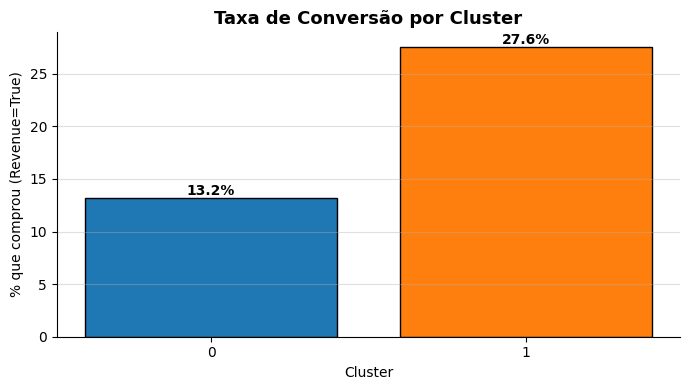

In [14]:
# Taxa de conversão (Revenue=True) por cluster
revenue_rate = data.groupby('Cluster')['Revenue'].mean().rename('Taxa de Conversão (%)')
revenue_rate = (revenue_rate * 100).round(2)
cluster_size = data.groupby('Cluster').size().rename('Tamanho')

summary = pd.concat([cluster_size, revenue_rate], axis=1)
print(summary)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(summary.index, summary['Taxa de Conversão (%)'],
              color=sns.color_palette('tab10', K_BEST), edgecolor='black')
for bar, val in zip(bars, summary['Taxa de Conversão (%)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', fontweight='bold')
ax.set_title('Taxa de Conversão por Cluster', fontsize=13, fontweight='bold')
ax.set_xlabel('Cluster')
ax.set_ylabel('% que comprou (Revenue=True)')
ax.set_xticks(summary.index)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('conversion_rate.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Interpretação dos Clusters

In [17]:
print('=' * 60)
print('RESUMO DOS CLUSTERS')
print('=' * 60)

for cl in sorted(data['Cluster'].unique()):
    sub = data[data['Cluster'] == cl]
    rev_rate = sub['Revenue'].mean() * 100
    pv_mean  = sub['PageValues'].mean()
    pr_mean  = sub['ProductRelated_Duration'].mean()
    br_mean  = sub['BounceRates'].mean()
    print(f'\nCluster {cl} ({len(sub)} usuários | {rev_rate:.1f}% converteram):')
    print(f'  PageValues médio:              {pv_mean:.2f}')
    print(f'  ProductRelated_Duration médio: {pr_mean:.0f} s')
    print(f'  BounceRates médio:             {br_mean:.4f}')

RESUMO DOS CLUSTERS

Cluster 0 (10378 usuários | 13.2% converteram):
  PageValues médio:              5.12
  ProductRelated_Duration médio: 753 s
  BounceRates médio:             0.0252

Cluster 1 (1952 usuários | 27.6% converteram):
  PageValues médio:              9.97
  ProductRelated_Duration médio: 3546 s
  BounceRates médio:             0.0062
